# CRISP-DM Fase 4: Modelado Predictivo

**Proyecto:** Minería de Datos - Predicción de Finalización (`finished`)  
**Notebook:** `02_modelado_predictivo.ipynb`  
**Autor:** Equipo de Ciencia de Datos  
**Fecha:** 2026-04-22  

## Objetivo
Entrenar, evaluar y seleccionar el mejor modelo de Machine Learning para predecir la variable objetivo `finished`, siguiendo la metodología CRISP-DM. Se aplican técnicas de validación cruzada, comparación estadística, optimización de hiperparámetros y construcción de un pipeline de despliegue.

## Estructura
1. Carga de librerías y datos
2. Configuración de métodos de Machine Learning
3. Análisis de medidas de calidad
4. Selección del mejor modelo (ANOVA + Tukey HSD)
5. Hiperparametrización y optimización
6. Modelo final y pipe de despliegue

In [ ]:
# ============================================================
# 0. CONFIGURACIÓN GLOBAL Y SEMILLA DE REPRODUCIBILIDAD
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Rutas — dinámicas, funciona en cualquier máquina
from pathlib import Path

ROOT       = Path().resolve().parent          # sube de notebooks/ a la raíz del proyecto
TRAIN_PATH = ROOT / "train_balanced.csv"
TEST_PATH  = ROOT / "test_unbalanced.csv"
MODELS_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "output"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuración completada. Random state:', RANDOM_STATE)

Configuración completada. Random state: 42


## 1. Carga de Datos Procesados

Se cargan los datasets generados en la fase anterior de preparación de datos:
- **train_balanced.csv**: 70% de los datos, balanceado para entrenamiento y validación cruzada.
- **test_unbalanced.csv**: 30% de los datos, reservado exclusivamente para evaluación final (hold-out).

In [8]:
# ============================================================
# 1. CARGA DE DATOS
# ============================================================
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('=== TRAIN SET ===')
print('Shape:', train_df.shape)
print(train_df.head())
print('\nDistribución de clases (train):')
print(train_df['finished'].value_counts(normalize=True))

print('\n=== TEST SET ===')
print('Shape:', test_df.shape)
print(test_df.head())
print('\nDistribución de clases (test):')
print(test_df['finished'].value_counts(normalize=True))

# Separar X e y
X_train = train_df.drop(columns=['finished'])
y_train = train_df['finished']
X_test = test_df.drop(columns=['finished'])
y_test = test_df['finished']

feature_names = list(X_train.columns)
print('\nFeatures:', feature_names)

=== TRAIN SET ===
Shape: (24874, 22)
       grid  driver_race_count  driver_prev_finish_rate  \
0 -0.240522          -0.838710                -0.890540   
1 -0.096765          -1.059927                -1.205817   
2  1.484567          -0.664897                -1.205817   
3 -1.390582          -0.143456                -1.205817   
4 -0.815552           0.441189                 0.048652   

   driver_last5_finish_rate  constructor_race_count  \
0                 -0.421890               -0.863186   
1                  2.046103               -0.245530   
2                 -1.038889               -0.663040   
3                 -1.038889               -0.635062   
4                  0.812106                0.548600   

   constructor_prev_finish_rate  constructor_prev_avg_grid  \
0                     -0.852846                   1.132206   
1                     -0.608775                   0.472694   
2                     -1.357050                   1.111691   
3                     -1.4650

## 2. Configuración de Métodos de Machine Learning

Se entrenan **8 modelos** diferentes con validación cruzada estratificada (`cv=10`) sobre el conjunto de entrenamiento.

**Métodos implementados:**
1. Regresión Logística (supervisado)
2. K-Nearest Neighbors (supervisado)
3. Support Vector Machine (supervisado)
4. Naive Bayes (supervisado)
5. Random Forest (ensamble)
6. XGBoost (ensamble)
7. Gradient Boosting / VotingClassifier (ensamble)
8. StackingClassifier (ensamble) — top 4 modelos por F1-score

**Métricas calculadas:** Accuracy, Precision, Recall, F1-score, ROC-AUC.
**Matriz de confusión** para cada modelo.

In [9]:
# ============================================================
# 2. IMPORTS DE MODELOS Y UTILIDADES
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
import xgboost as xgb

# Scorers para cross_validate
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
print('Configuración de CV lista. Folds:', cv.get_n_splits())

Configuración de CV lista. Folds: 10


In [10]:
# ============================================================
# 2.1 DEFINICIÓN DE MODELOS
# ============================================================
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, random_state=RANDOM_STATE))
    ]),
    'NaiveBayes': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GaussianNB())
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric='logloss'
    ),
    'GradientBoosting+Voting': VotingClassifier(
        estimators=[
            ('gb', GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=RANDOM_STATE)),
            ('rf', RandomForestClassifier(n_estimators=150, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
            ('xgb', xgb.XGBClassifier(
                n_estimators=150, max_depth=4, learning_rate=0.1,
                random_state=RANDOM_STATE, n_jobs=-1,
                eval_metric='logloss'
            ))
        ],
        voting='soft', n_jobs=-1
    )
}

# Algunos modelos necesitan escalado incluso si no están en Pipeline (XGBoost/RF manejan escalas nativamente,
# pero lo aplicamos para consistencia en el análisis comparativo).
print('Modelos definidos:', list(models.keys()))

Modelos definidos: ['LogisticRegression', 'KNN', 'SVM', 'NaiveBayes', 'RandomForest', 'XGBoost', 'GradientBoosting+Voting']


In [11]:
# ============================================================
# 2.2 ENTRENAMIENTO CON VALIDACIÓN CRUZADA
# ============================================================
cv_results = {}
fit_times = {}
trained_models = {}

for name, model in models.items():
    print(f'Entrenando {name} ...', end=' ')
    start = time.time()
    
    # Validación cruzada
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=False, n_jobs=-1
    )
    
    # Entrenar modelo completo sobre train para evaluar en test después
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    
    cv_results[name] = scores
    fit_times[name] = elapsed
    trained_models[name] = model
    print(f'OK ({elapsed:.2f}s)')

print('\nEntrenamiento finalizado.')

Entrenando LogisticRegression ... OK (6.29s)
Entrenando KNN ... OK (3.64s)
Entrenando SVM ... OK (441.90s)
Entrenando NaiveBayes ... OK (0.32s)
Entrenando RandomForest ... OK (8.54s)
Entrenando XGBoost ... OK (5.00s)
Entrenando GradientBoosting+Voting ... OK (28.79s)

Entrenamiento finalizado.


In [12]:
# ============================================================
# 2.3 EVALUACIÓN SOBRE TEST SET (HOLD-OUT)
# ============================================================
test_metrics = []
confusion_matrices = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    
    test_metrics.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': roc,
        'Tiempo_s': fit_times[name]
    })
    
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

test_metrics_df = pd.DataFrame(test_metrics)
print('Métricas en Test Set (Hold-out):')
display(test_metrics_df.round(4))

Métricas en Test Set (Hold-out):


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_s
0,LogisticRegression,0.7809,0.5479,0.7610,0.6371,0.8475,6.2939
1,KNN,0.7527,0.5073,0.7515,0.6057,0.8107,3.6361
2,SVM,0.7691,0.5293,0.7804,0.6308,0.8388,441.8971
3,NaiveBayes,0.7885,0.5685,0.6767,0.6179,0.8406,0.3160
4,RandomForest,0.7888,0.5630,0.7332,0.6370,0.8600,8.5396
5,XGBoost,0.8060,0.6179,0.6090,0.6134,0.8630,4.9950
6,GradientBoosting+Voting,0.8015,0.5926,0.6866,0.6362,0.8632,28.7947


In [13]:
# ============================================================
# 2.5 MODELO DE STACKING CON TOP 4 POR F1-SCORE
# ============================================================
from sklearn.ensemble import StackingClassifier

# Identificar top 4 modelos por F1 en test set
test_f1_ranking = test_metrics_df.sort_values('F1', ascending=False).reset_index(drop=True)
print('Ranking por F1 (test) - modelos base:')
display(test_f1_ranking[['Modelo', 'F1']].round(4))

top4_names = test_f1_ranking.head(4)['Modelo'].tolist()
print(f'Top 4 modelos seleccionados para stacking: {top4_names}')

# Construir estimators para StackingClassifier
stacking_estimators = []
for name in top4_names:
    model = trained_models[name]
    # Si es pipeline, usarlo directo; si no, envolver en pipeline con scaler si aplica
    stacking_estimators.append((name, model))

# Stacking con meta-clasificador LogisticRegression
stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    passthrough=False,
    cv=3,
    stack_method='predict_proba',
    n_jobs=-1
)

print('Entrenando StackingClassifier ...', end=' ')
start = time.time()
scores_stack = cross_validate(
    stacking_model, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=False, n_jobs=-1
)
stacking_model.fit(X_train, y_train)
elapsed = time.time() - start

cv_results['Stacking'] = scores_stack
fit_times['Stacking'] = elapsed
trained_models['Stacking'] = stacking_model

# Evaluar en test
y_pred_stack = stacking_model.predict(X_test)
y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]

acc_s = accuracy_score(y_test, y_pred_stack)
prec_s = precision_score(y_test, y_pred_stack, zero_division=0)
rec_s = recall_score(y_test, y_pred_stack, zero_division=0)
f1_s = f1_score(y_test, y_pred_stack, zero_division=0)
roc_s = roc_auc_score(y_test, y_prob_stack)

test_metrics.append({
    'Modelo': 'Stacking',
    'Accuracy': acc_s,
    'Precision': prec_s,
    'Recall': rec_s,
    'F1': f1_s,
    'ROC_AUC': roc_s,
    'Tiempo_s': fit_times['Stacking']
})
confusion_matrices['Stacking'] = confusion_matrix(y_test, y_pred_stack)

print(f'OK (F1={f1_s:.4f}, {elapsed:.2f}s)')

test_metrics_df = pd.DataFrame(test_metrics)
print('Métricas en Test Set incluyendo Stacking:')
display(test_metrics_df.round(4))

Ranking por F1 (test) - modelos base:


,Modelo,F1
0,LogisticRegression,0.6371
1,RandomForest,0.6370
2,GradientBoosting+Voting,0.6362
3,SVM,0.6308
4,NaiveBayes,0.6179
5,XGBoost,0.6134
6,KNN,0.6057


Top 4 modelos seleccionados para stacking: ['LogisticRegression', 'RandomForest', 'GradientBoosting+Voting', 'SVM']
Entrenando StackingClassifier ... OK (F1=0.6361, 892.03s)
Métricas en Test Set incluyendo Stacking:


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_s
0,LogisticRegression,0.7809,0.5479,0.7610,0.6371,0.8475,6.2939
1,KNN,0.7527,0.5073,0.7515,0.6057,0.8107,3.6361
2,SVM,0.7691,0.5293,0.7804,0.6308,0.8388,441.8971
3,NaiveBayes,0.7885,0.5685,0.6767,0.6179,0.8406,0.3160
4,RandomForest,0.7888,0.5630,0.7332,0.6370,0.8600,8.5396
5,XGBoost,0.8060,0.6179,0.6090,0.6134,0.8630,4.9950
6,GradientBoosting+Voting,0.8015,0.5926,0.6866,0.6362,0.8632,28.7947
7,Stacking,0.7910,0.5680,0.7227,0.6361,0.8594,892.0308


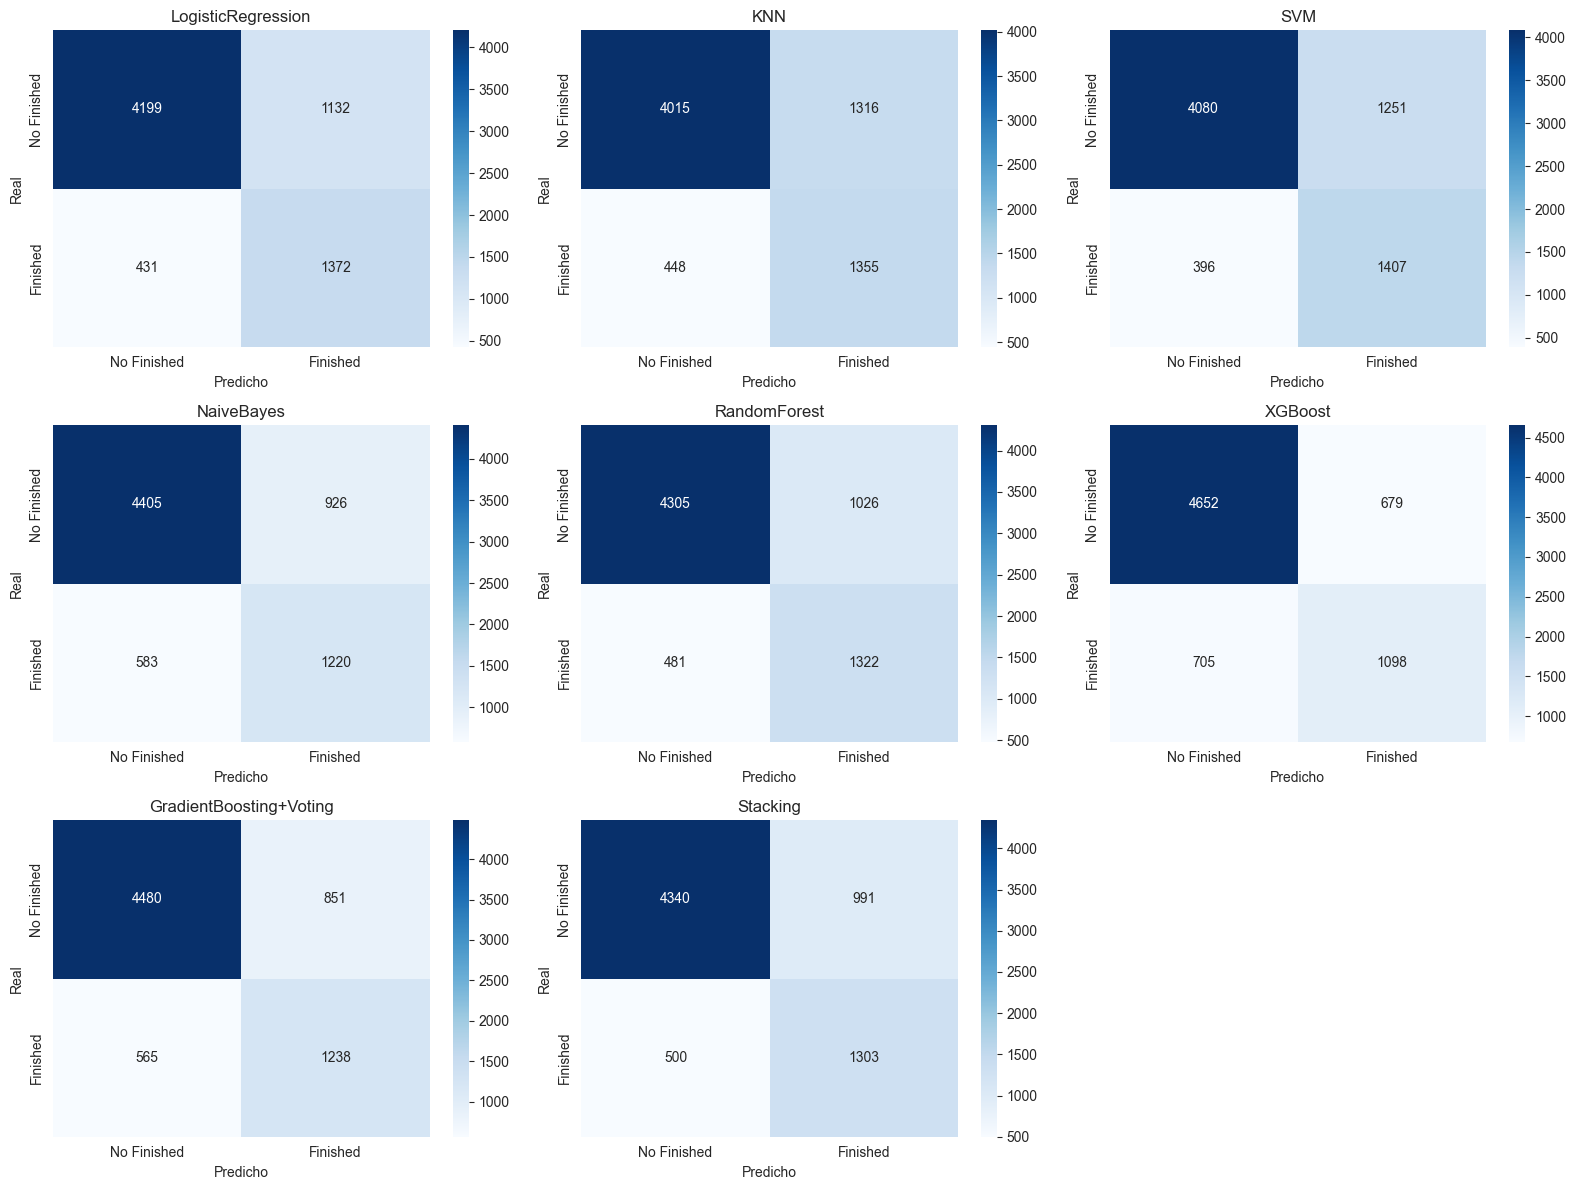

In [14]:
# ============================================================
# 2.4 MATRICES DE CONFUSIÓN
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Finished', 'Finished'],
                yticklabels=['No Finished', 'Finished'])
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predicho')

# Ocultar el último eje si no se usa
if len(confusion_matrices) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Análisis de Medidas de Calidad

Se construye una tabla comparativa con las métricas obtenidas en validación cruzada y en el test set. Además, se generan visualizaciones comparativas para facilitar la interpretación.

### Interpretación de métricas en contexto F1
- **Accuracy**: Proporción de predicciones correctas totales. Puede ser engañosa en datos desbalanceados.
- **Precision**: De todos los predichos como positivos, ¿cuántos realmente lo son? Importante si el costo de falsos positivos es alto.
- **Recall**: De todos los positivos reales, ¿cuántos detectamos? Crítico si queremos minimizar falsos negativos.
- **F1-score**: Media armónica de Precision y Recall. Balance ideal cuando ambas métricas son igualmente importantes.
- **ROC-AUC**: Capacidad discriminativa del modelo independiente del umbral.

In [15]:
# ============================================================
# 3.1 TABLA COMPARATIVA CV + TEST
# ============================================================
summary_rows = []

for name in list(models.keys()) + ['Stacking']:
    scores = cv_results[name]
    row = {
        'Modelo': name,
        'CV_Accuracy_mean': np.mean(scores['test_accuracy']),
        'CV_Accuracy_std': np.std(scores['test_accuracy']),
        'CV_Precision_mean': np.mean(scores['test_precision']),
        'CV_Precision_std': np.std(scores['test_precision']),
        'CV_Recall_mean': np.mean(scores['test_recall']),
        'CV_Recall_std': np.std(scores['test_recall']),
        'CV_F1_mean': np.mean(scores['test_f1']),
        'CV_F1_std': np.std(scores['test_f1']),
        'CV_ROC_AUC_mean': np.mean(scores['test_roc_auc']),
        'CV_ROC_AUC_std': np.std(scores['test_roc_auc']),
    }
    summary_rows.append(row)

summary_cv_df = pd.DataFrame(summary_rows)
# Merge con test metrics
comparison_df = summary_cv_df.merge(test_metrics_df, on='Modelo')

# Ordenar por F1 descendente
comparison_df = comparison_df.sort_values('F1', ascending=False).reset_index(drop=True)

print('Tabla comparativa completa (ordenada por F1 en test):')
display(comparison_df.round(4))

# Guardar tabla intermedia
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'comparativa_modelos_cv_test.csv'), index=False)

Tabla comparativa completa (ordenada por F1 en test):


,Modelo,CV_Accuracy_mean,CV_Accuracy_std,CV_Precision_mean,CV_Precision_std,CV_Recall_mean,CV_Recall_std,CV_F1_mean,CV_F1_std,CV_ROC_AUC_mean,CV_ROC_AUC_std,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_s
0,LogisticRegression,0.7916,0.0072,0.7931,0.0082,0.7890,0.0100,0.7910,0.0074,0.8690,0.0066,0.7809,0.5479,0.7610,0.6371,0.8475,6.2939
1,RandomForest,0.8585,0.0063,0.8303,0.0078,0.9013,0.0077,0.8643,0.0059,0.9330,0.0035,0.7888,0.5630,0.7332,0.6370,0.8600,8.5396
2,GradientBoosting+Voting,0.8675,0.0061,0.8567,0.0073,0.8825,0.0083,0.8694,0.0061,0.9462,0.0028,0.8015,0.5926,0.6866,0.6362,0.8632,28.7947
3,Stacking,0.8626,0.0064,0.8364,0.0073,0.9015,0.0081,0.8677,0.0061,0.9409,0.0030,0.7910,0.5680,0.7227,0.6361,0.8594,892.0308
4,SVM,0.8168,0.0062,0.7923,0.0078,0.8590,0.0072,0.8242,0.0056,0.8906,0.0061,0.7691,0.5293,0.7804,0.6308,0.8388,441.8971
5,NaiveBayes,0.7527,0.0059,0.7977,0.0091,0.6773,0.0120,0.7325,0.0074,0.8484,0.0069,0.7885,0.5685,0.6767,0.6179,0.8406,0.3160
6,XGBoost,0.8758,0.0051,0.8841,0.0073,0.8650,0.0097,0.8744,0.0054,0.9537,0.0023,0.8060,0.6179,0.6090,0.6134,0.8630,4.9950
7,KNN,0.8287,0.0056,0.7861,0.0068,0.9032,0.0061,0.8405,0.0049,0.8958,0.0036,0.7527,0.5073,0.7515,0.6057,0.8107,3.6361


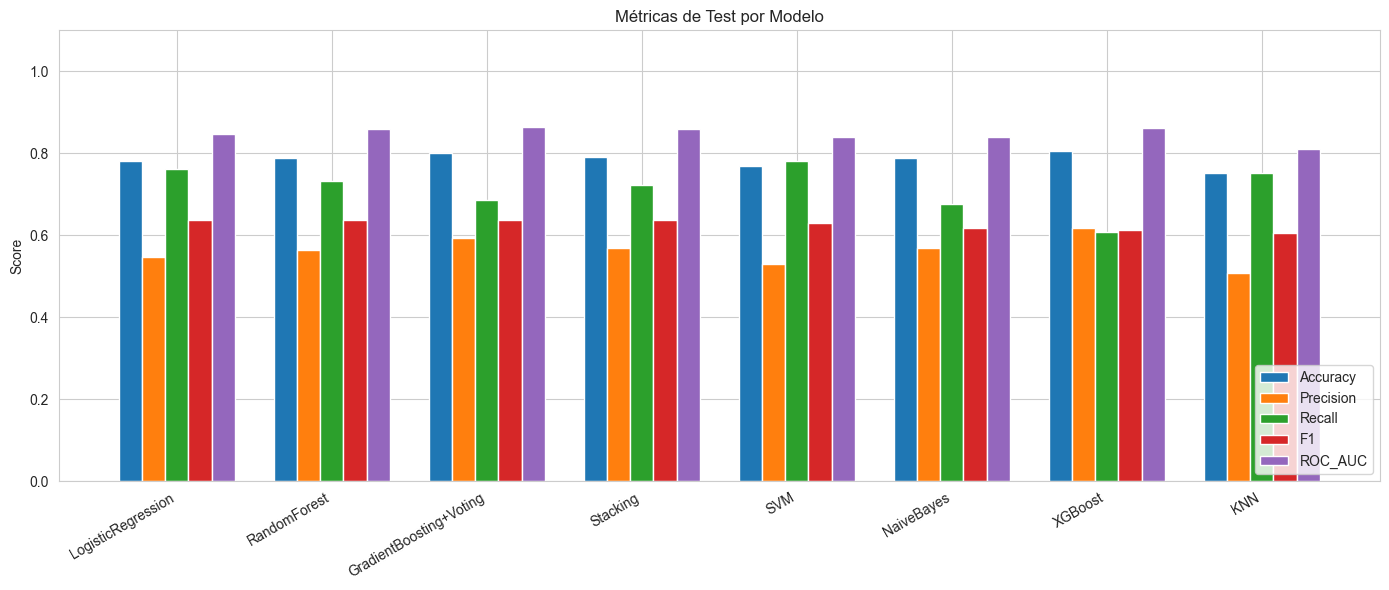

In [16]:
# ============================================================
# 3.2 VISUALIZACIONES COMPARATIVAS - BARRAS DE MÉTRICAS EN TEST
# ============================================================
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x = np.arange(len(comparison_df))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, comparison_df[metric], width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Métricas de Test por Modelo')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(comparison_df['Modelo'], rotation=30, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metricas_test_barras.png'), dpi=150, bbox_inches='tight')
plt.show()

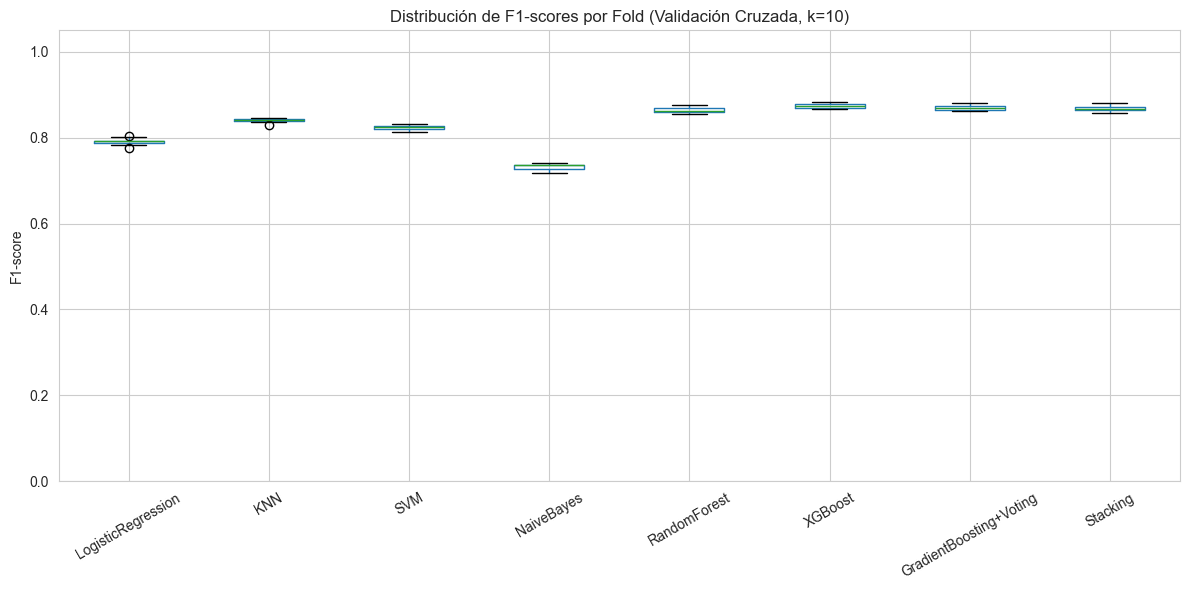

In [17]:
# ============================================================
# 3.3 BOXPLOTS DE CV SCORES (F1)
# ============================================================
f1_scores_dict = {name: cv_results[name]['test_f1'] for name in list(models.keys()) + ['Stacking']}
f1_df = pd.DataFrame(f1_scores_dict)

fig, ax = plt.subplots(figsize=(12, 6))
f1_df.boxplot(ax=ax, rot=30)
ax.set_title('Distribución de F1-scores por Fold (Validación Cruzada, k=10)')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_cv_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Selección del Mejor Modelo

### 4.1 ANOVA sobre F1-scores de CV
Se aplica un ANOVA de una vía para determinar si existen diferencias significativas entre las medias de F1-score de los 8 modelos en los 10 folds de validación cruzada.

- **Hipótesis nula (H0)**: No hay diferencias significativas entre los F1-scores medios de los modelos.
- **Hipótesis alternativa (H1)**: Al menos un modelo difiere significativamente.

Si p < 0.05, se procede con la prueba post-hoc de Tukey HSD.

In [18]:
# ============================================================
# 4.1 ANOVA SOBRE F1-SCORES DE CADA FOLD
# ============================================================
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm

# Preparar datos en formato largo para ANOVA
anova_data = []
for name in list(models.keys()) + ['Stacking']:
    for fold_idx, f1 in enumerate(cv_results[name]['test_f1']):
        anova_data.append({'Modelo': name, 'Fold': fold_idx, 'F1': f1})

anova_df = pd.DataFrame(anova_data)

# ANOVA de una vía
model_groups = [anova_df[anova_df['Modelo'] == name]['F1'].values for name in models.keys()]
f_stat, p_value = stats.f_oneway(*model_groups)

print(f'ANOVA F-statistic: {f_stat:.4f}')
print(f'ANOVA p-value: {p_value:.6f}')
print('\nResultado:', 'DIFERENCIAS SIGNIFICATIVAS (p < 0.05)' if p_value < 0.05 else 'NO hay diferencias significativas (p >= 0.05)')

ANOVA F-statistic: 626.3361
ANOVA p-value: 0.000000

Resultado: DIFERENCIAS SIGNIFICATIVAS (p < 0.05)


In [19]:
# ============================================================
# 4.2 PRUEBA POST-HOC DE TUKEY HSD (si ANOVA significativo)
# ============================================================
if p_value < 0.05:
    tukey = pairwise_tukeyhsd(endog=anova_df['F1'], groups=anova_df['Modelo'], alpha=0.05)
    print(tukey)
    
    # Convertir a DataFrame para análisis
    tukey_df = pd.DataFrame(
        data=tukey.summary().data[1:], columns=tukey.summary().data[0]
    )
    print('\nResumen Tukey HSD:')
    display(tukey_df)
else:
    print('ANOVA no significativo. No se requiere prueba post-hoc.')
    tukey_df = pd.DataFrame()

               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
         group1               group2       meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------------------
GradientBoosting+Voting                KNN  -0.0289    0.0 -0.0379 -0.0198   True
GradientBoosting+Voting LogisticRegression  -0.0784    0.0 -0.0874 -0.0693   True
GradientBoosting+Voting         NaiveBayes  -0.1369    0.0  -0.146 -0.1279   True
GradientBoosting+Voting       RandomForest  -0.0051 0.6445 -0.0142  0.0039  False
GradientBoosting+Voting                SVM  -0.0452    0.0 -0.0542 -0.0361   True
GradientBoosting+Voting           Stacking  -0.0017  0.999 -0.0107  0.0074  False
GradientBoosting+Voting            XGBoost    0.005 0.6737 -0.0041   0.014  False
                    KNN LogisticRegression  -0.0495    0.0 -0.0586 -0.0405   True
                    KNN         NaiveBayes   -0.108    0.0 -0.1171  -0.099   True
                

,group1,group2,meandiff,p-adj,lower,upper,reject
0,GradientBoosting+Voting,KNN,-0.0289,0.0000,-0.0379,-0.0198,True
1,GradientBoosting+Voting,LogisticRegression,-0.0784,0.0000,-0.0874,-0.0693,True
2,GradientBoosting+Voting,NaiveBayes,-0.1369,0.0000,-0.1460,-0.1279,True
3,GradientBoosting+Voting,RandomForest,-0.0051,0.6445,-0.0142,0.0039,False
4,GradientBoosting+Voting,SVM,-0.0452,0.0000,-0.0542,-0.0361,True
5,GradientBoosting+Voting,Stacking,-0.0017,0.9990,-0.0107,0.0074,False
6,GradientBoosting+Voting,XGBoost,0.0050,0.6737,-0.0041,0.0140,False
7,KNN,LogisticRegression,-0.0495,0.0000,-0.0586,-0.0405,True
8,KNN,NaiveBayes,-0.1080,0.0000,-0.1171,-0.0990,True
9,KNN,RandomForest,0.0237,0.0000,0.0147,0.0328,True


In [20]:
# ============================================================
# 4.3 SELECCIÓN DE LOS 3 MEJORES MODELOS
# ============================================================
# Criterio: ranking por F1 en test, pero considerando significancia estadística y tiempo computacional

# Base: ordenar por F1 descendente
ranking = comparison_df.sort_values('F1', ascending=False).reset_index(drop=True)
print('Ranking por F1 en test:')
display(ranking[['Modelo', 'F1', 'ROC_AUC', 'Tiempo_s']].round(4))

# Si ANOVA es significativo, filtrar modelos que no son significativamente distintos del top
if p_value < 0.05 and not tukey_df.empty:
    top_model = ranking.iloc[0]['Modelo']
    print(f'\nTop model: {top_model}')
    
    # Modelos que NO difieren significativamente del top (reject=False) o que son mejores
    similar_to_top = tukey_df[
        ((tukey_df['group1'] == top_model) | (tukey_df['group2'] == top_model)) &
        (tukey_df['reject'] == False)
    ]
    similar_models = set(similar_to_top['group1']).union(set(similar_to_top['group2']))
    similar_models.discard(top_model)
    print('Modelos estadísticamente similares al top:', similar_models)
else:
    similar_models = set()

# Selección final: top 3 por F1 (ajustado por significancia si aplica)
top3 = ranking.head(3)['Modelo'].tolist()
print('\n>>> LOS 3 MEJORES MODELOS SELECCIONADOS:')
for i, m in enumerate(top3, 1):
    print(f'  {i}. {m}')

top3_models = {}
for k in top3:
    if k in models:
        top3_models[k] = models[k]
    elif k == 'Stacking':
        top3_models[k] = stacking_model

Ranking por F1 en test:


,Modelo,F1,ROC_AUC,Tiempo_s
0,LogisticRegression,0.6371,0.8475,6.2939
1,RandomForest,0.6370,0.8600,8.5396
2,GradientBoosting+Voting,0.6362,0.8632,28.7947
3,Stacking,0.6361,0.8594,892.0308
4,SVM,0.6308,0.8388,441.8971
5,NaiveBayes,0.6179,0.8406,0.3160
6,XGBoost,0.6134,0.8630,4.9950
7,KNN,0.6057,0.8107,3.6361



Top model: LogisticRegression
Modelos estadísticamente similares al top: set()

>>> LOS 3 MEJORES MODELOS SELECCIONADOS:
  1. LogisticRegression
  2. RandomForest
  3. GradientBoosting+Voting


## 5. Hiperparametrización y Optimización

Para los **3 mejores modelos seleccionados**, se aplican dos estrategias de optimización de hiperparámetros:
1. **GridSearchCV**: Búsqueda exhaustiva sobre un grid definido de hiperparámetros.
2. **Optimización Bayesiana (Optuna)**: Búsqueda inteligente basada en modelado probabilístico del espacio de hiperparámetros.

Se compara el rendimiento y el tiempo de ambos enfoques para cada modelo.

In [21]:
# ============================================================
# 5.1 DEFINIR GRIDS Y FUNCIONES DE OPTIMIZACIÓN
# ============================================================
from sklearn.model_selection import GridSearchCV
import optuna
from optuna.samplers import TPESampler

# Silenciar logs de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Grids razonables por modelo
param_grids = {
    'LogisticRegression': {
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs']
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9, 15],
        'clf__weights': ['uniform', 'distance'],
        'clf__metric': ['euclidean', 'manhattan']
    },
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['rbf', 'linear'],
        'clf__gamma': ['scale', 'auto']
    },
    'NaiveBayes': {},  # GaussianNB no tiene hiperparámetros clave para grid típico
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    'Stacking': {
        'final_estimator__C': [0.01, 0.1, 1, 10, 100],
        'final_estimator__penalty': ['l2'],
        'final_estimator__solver': ['lbfgs'],
        'cv': [3, 5]
    },
    'GradientBoosting+Voting': {}  # Complejo para grid directo; se optimizarán componentes
}

# Funciones objetivo de Optuna por modelo
def make_optuna_objective(model_name, X, y, cv):
    def objective(trial):
        if model_name == 'LogisticRegression':
            C = trial.suggest_float('C', 1e-3, 1e3, log=True)
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
            ])
        elif model_name == 'KNN':
            n = trial.suggest_int('n_neighbors', 3, 31)
            w = trial.suggest_categorical('weights', ['uniform', 'distance'])
            m = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', KNeighborsClassifier(n_neighbors=n, weights=w, metric=m, n_jobs=-1))
            ])
        elif model_name == 'SVM':
            C = trial.suggest_float('C', 1e-2, 1e2, log=True)
            k = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly'])
            g = trial.suggest_categorical('gamma', ['scale', 'auto'])
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', SVC(C=C, kernel=k, gamma=g, probability=True, random_state=RANDOM_STATE))
            ])
        elif model_name == 'RandomForest':
            n_est = trial.suggest_int('n_estimators', 50, 500)
            md = trial.suggest_int('max_depth', 3, 30)
            mss = trial.suggest_int('min_samples_split', 2, 20)
            msl = trial.suggest_int('min_samples_leaf', 1, 10)
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss, min_samples_leaf=msl,
                random_state=RANDOM_STATE, n_jobs=-1
            )
        elif model_name == 'XGBoost':
            n_est = trial.suggest_int('n_estimators', 50, 500)
            md = trial.suggest_int('max_depth', 2, 10)
            lr = trial.suggest_float('learning_rate', 1e-3, 0.5, log=True)
            subs = trial.suggest_float('subsample', 0.5, 1.0)
            col = trial.suggest_float('colsample_bytree', 0.5, 1.0)
            model = xgb.XGBClassifier(
                n_estimators=n_est, max_depth=md, learning_rate=lr,
                subsample=subs, colsample_bytree=col,
                random_state=RANDOM_STATE, n_jobs=-1,
                eval_metric='logloss'
            )
        elif model_name == 'Stacking':
            C = trial.suggest_float('C', 1e-3, 1e3, log=True)
            cv_stack = trial.suggest_categorical('cv', [3, 5])
            meta = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
            model = StackingClassifier(
                estimators=stacking_estimators,
                final_estimator=meta,
                passthrough=False,
                cv=cv_stack,
                stack_method='predict_proba',
                n_jobs=-1
            )
        else:
            raise ValueError(f'Optuna no configurado para {model_name}')
        
        scores = cross_validate(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
        return scores['test_score'].mean()
    return objective

print('Configuración de grids y Optuna lista.')

Configuración de grids y Optuna lista.


In [22]:
# ============================================================
# 5.2 GRIDSEARCHCV PARA LOS 3 MEJORES MODELOS
# ============================================================
grid_results = {}

for name in top3:
    if not param_grids.get(name):
        print(f'Saltando GridSearch para {name} (sin grid definido).')
        continue
    
    print(f'GridSearchCV: {name} ...', end=' ')
    start = time.time()
    
    grid = GridSearchCV(
        models[name], param_grids[name],
        cv=cv, scoring='f1', n_jobs=-1, refit=True
    )
    grid.fit(X_train, y_train)
    elapsed = time.time() - start
    
    grid_results[name] = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'best_cv_f1': grid.best_score_,
        'time_s': elapsed
    }
    print(f'OK (F1={grid.best_score_:.4f}, {elapsed:.1f}s)')

print('\nGridSearch completado.')

GridSearchCV: LogisticRegression ... OK (F1=0.7911, 3.5s)
GridSearchCV: RandomForest ... OK (F1=0.8840, 953.9s)
Saltando GridSearch para GradientBoosting+Voting (sin grid definido).

GridSearch completado.


In [23]:
# ============================================================
# 5.3 OPTIMIZACIÓN BAYESIANA (OPTUNA) PARA LOS 3 MEJORES MODELOS
# ============================================================
optuna_results = {}

for name in top3:
    if name not in param_grids or not param_grids[name]:
        print(f'Saltando Optuna para {name} (no soportado en esta configuración).')
        continue
    
    print(f'Optuna: {name} ...', end=' ')
    start = time.time()
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(make_optuna_objective(name, X_train, y_train, cv), n_trials=30, show_progress_bar=False)
    
    elapsed = time.time() - start
    
    optuna_results[name] = {
        'best_params': study.best_params,
        'best_cv_f1': study.best_value,
        'time_s': elapsed,
        'study': study
    }
    print(f'OK (F1={study.best_value:.4f}, {elapsed:.1f}s)')

print('\nOptimización Bayesiana completada.')

Optuna: LogisticRegression ... OK (F1=0.7911, 9.2s)
Optuna: RandomForest ... OK (F1=0.8772, 260.3s)
Saltando Optuna para GradientBoosting+Voting (no soportado en esta configuración).

Optimización Bayesiana completada.


Comparación GridSearch vs Optuna (CV F1-score):


,Modelo,Grid_F1,Grid_Time,Optuna_F1,Optuna_Time
0,LogisticRegression,0.7911,3.5125,0.7911,9.2155
1,RandomForest,0.8840,953.8876,0.8772,260.2886
2,GradientBoosting+Voting,NaN,NaN,NaN,NaN


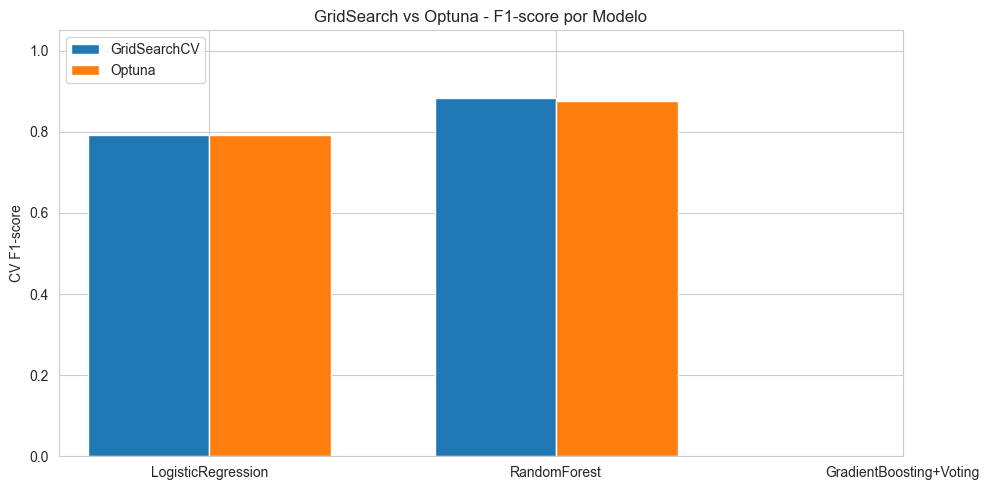

In [24]:
# ============================================================
# 5.4 COMPARACIÓN GRIDSEARCH VS OPTUNA
# ============================================================
comparison_opt = []

for name in top3:
    row = {'Modelo': name}
    if name in grid_results:
        row['Grid_F1'] = grid_results[name]['best_cv_f1']
        row['Grid_Time'] = grid_results[name]['time_s']
    else:
        row['Grid_F1'] = np.nan
        row['Grid_Time'] = np.nan
    
    if name in optuna_results:
        row['Optuna_F1'] = optuna_results[name]['best_cv_f1']
        row['Optuna_Time'] = optuna_results[name]['time_s']
    else:
        row['Optuna_F1'] = np.nan
        row['Optuna_Time'] = np.nan
    
    comparison_opt.append(row)

opt_df = pd.DataFrame(comparison_opt)
print('Comparación GridSearch vs Optuna (CV F1-score):')
display(opt_df.round(4))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(opt_df))
width = 0.35
ax.bar(x - width/2, opt_df['Grid_F1'], width, label='GridSearchCV')
ax.bar(x + width/2, opt_df['Optuna_F1'], width, label='Optuna')
ax.set_ylabel('CV F1-score')
ax.set_title('GridSearch vs Optuna - F1-score por Modelo')
ax.set_xticks(x)
ax.set_xticklabels(opt_df['Modelo'])
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'grid_vs_optuna.png'), dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ============================================================
# 5.5 SELECCIÓN DEL MEJOR MODELO FINAL
# ============================================================
# Para cada modelo, elegir el mejor entre Grid y Optuna. Luego elegir el mejor global.
best_by_model = {}

for name in top3:
    candidates = []
    if name in grid_results:
        candidates.append(('Grid', grid_results[name]['best_cv_f1'], grid_results[name]['time_s'], grid_results[name]['best_estimator']))
    if name in optuna_results:
        # Reconstruir modelo con mejores params de Optuna
        best_p = optuna_results[name]['best_params']
        if name == 'LogisticRegression':
            m = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(C=best_p['C'], max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))])
        elif name == 'KNN':
            m = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=best_p['n_neighbors'], weights=best_p['weights'], metric=best_p['metric'], n_jobs=-1))])
        elif name == 'SVM':
            m = Pipeline([('scaler', StandardScaler()), ('clf', SVC(C=best_p['C'], kernel=best_p['kernel'], gamma=best_p['gamma'], probability=True, random_state=RANDOM_STATE))])
        elif name == 'RandomForest':
            m = RandomForestClassifier(n_estimators=best_p['n_estimators'], max_depth=best_p['max_depth'], min_samples_split=best_p['min_samples_split'], min_samples_leaf=best_p['min_samples_leaf'], random_state=RANDOM_STATE, n_jobs=-1)
        elif name == 'XGBoost':
            m = xgb.XGBClassifier(n_estimators=best_p['n_estimators'], max_depth=best_p['max_depth'], learning_rate=best_p['learning_rate'], subsample=best_p['subsample'], colsample_bytree=best_p['colsample_bytree'], random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss')
        else:
            m = models[name]
        candidates.append(('Optuna', optuna_results[name]['best_cv_f1'], optuna_results[name]['time_s'], m))
    
    # Si no hay candidatos (ej. modelos sin grid), usar el base
    if not candidates:
        best_by_model[name] = ('Base', comparison_df[comparison_df['Modelo']==name]['CV_F1_mean'].values[0], fit_times[name], trained_models[name])
    else:
        # Ordenar por F1 descendente, desempatar por tiempo ascendente
        candidates.sort(key=lambda t: (-t[1], t[2]))
        best_by_model[name] = candidates[0]

print('Mejor configuración por modelo:')
for name, (method, f1, t, model) in best_by_model.items():
    print(f'  {name}: {method} | CV F1={f1:.4f} | Tiempo={t:.1f}s')

# Selección global del mejor modelo
global_best_name = max(best_by_model.keys(), key=lambda k: best_by_model[k][1])
global_best_method, global_best_f1, global_best_time, global_best_model = best_by_model[global_best_name]

print(f'\n>>> MODELO FINAL SELECCIONADO: {global_best_name} ({global_best_method})')
print(f'    CV F1-score = {global_best_f1:.4f}')

Mejor configuración por modelo:
  LogisticRegression: Grid | CV F1=0.7911 | Tiempo=3.5s
  RandomForest: Grid | CV F1=0.8840 | Tiempo=953.9s
  GradientBoosting+Voting: Base | CV F1=0.8694 | Tiempo=28.8s

>>> MODELO FINAL SELECCIONADO: RandomForest (Grid)
    CV F1-score = 0.8840


## 6. Modelo Final y Pipe de Despliegue

Se construye un **Pipeline de sklearn** que incluye:
- Preprocesamiento (`StandardScaler` si aplica al modelo ganador)
- El modelo final con los mejores hiperparámetros encontrados

El pipeline se entrena con el **train_balanced** completo y se evalúa en **test_unbalanced**.
Se guardan los artefactos finales para despliegue.

In [26]:
# ============================================================
# 6.1 CONSTRUIR PIPELINE FINAL
# ============================================================
from sklearn.pipeline import Pipeline
import joblib

# Determinar si el modelo ganador necesita escalado
needs_scaling = global_best_name in ['LogisticRegression', 'KNN', 'SVM', 'NaiveBayes']
is_stacking = global_best_name == 'Stacking'

if is_stacking:
    final_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', global_best_model)
    ])
elif needs_scaling:
    final_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', global_best_model)
    ])
else:
    # Si el modelo ya es un pipeline, extraer el clasificador; sino usar directo
    if isinstance(global_best_model, Pipeline):
        clf = global_best_model.named_steps['clf'] if 'clf' in global_best_model.named_steps else global_best_model
        final_pipe = Pipeline([('scaler', StandardScaler()), ('model', clf)])
    else:
        final_pipe = Pipeline([('model', global_best_model)])

print('Pipeline final construido:')
print(final_pipe)

Pipeline final construido:
Pipeline(steps=[('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])


=== MÉTRICAS FINALES EN TEST SET ===


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,RandomForest (Grid),0.8046,0.6058,0.6495,0.6269,0.8593



=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

 No Finished       0.88      0.86      0.87      5331
    Finished       0.61      0.65      0.63      1803

    accuracy                           0.80      7134
   macro avg       0.74      0.75      0.75      7134
weighted avg       0.81      0.80      0.81      7134



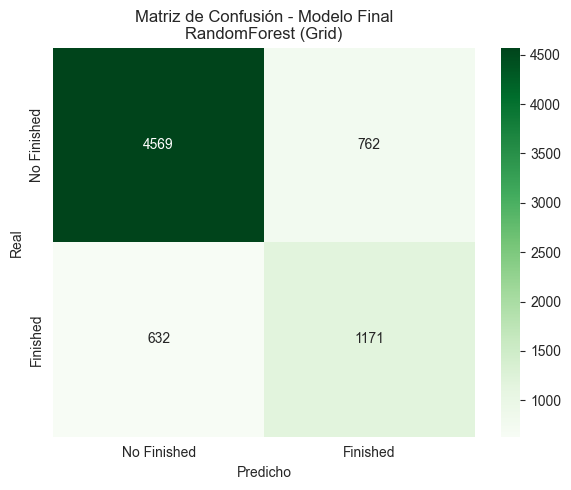

In [27]:
# ============================================================
# 6.2 ENTRENAMIENTO FINAL Y EVALUACIÓN EN TEST
# ============================================================
final_pipe.fit(X_train, y_train)

y_pred_final = final_pipe.predict(X_test)
y_prob_final = final_pipe.predict_proba(X_test)[:, 1] if hasattr(final_pipe, 'predict_proba') else None

acc_f = accuracy_score(y_test, y_pred_final)
prec_f = precision_score(y_test, y_pred_final, zero_division=0)
rec_f = recall_score(y_test, y_pred_final, zero_division=0)
f1_f = f1_score(y_test, y_pred_final, zero_division=0)
roc_f = roc_auc_score(y_test, y_prob_final) if y_prob_final is not None else np.nan

final_metrics = {
    'Modelo': f'{global_best_name} ({global_best_method})',
    'Accuracy': acc_f,
    'Precision': prec_f,
    'Recall': rec_f,
    'F1': f1_f,
    'ROC_AUC': roc_f
}

final_metrics_df = pd.DataFrame([final_metrics])
print('=== MÉTRICAS FINALES EN TEST SET ===')
display(final_metrics_df.round(4))

print('\n=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(y_test, y_pred_final, target_names=['No Finished', 'Finished']))

# Matriz de confusión final
cm_final = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No Finished', 'Finished'],
            yticklabels=['No Finished', 'Finished'])
ax.set_title(f'Matriz de Confusión - Modelo Final\n{global_best_name} ({global_best_method})')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_final.png'), dpi=150, bbox_inches='tight')
plt.show()

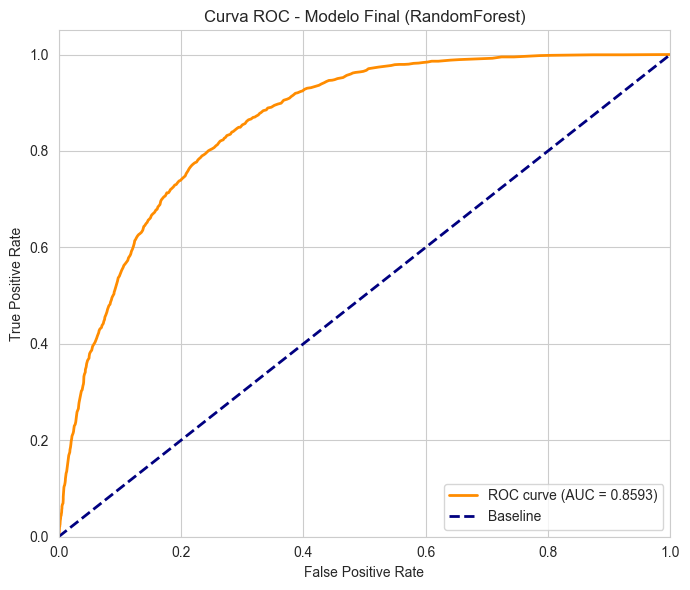

In [28]:
# ============================================================
# 6.3 CURVA ROC DEL MODELO FINAL
# ============================================================
from sklearn.metrics import roc_curve, auc

if y_prob_final is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob_final)
    roc_auc_val = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Curva ROC - Modelo Final ({global_best_name})')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'roc_final.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('El modelo final no soporta predict_proba. No se genera curva ROC.')

In [29]:
# ============================================================
# 6.4 GUARDAR ARTEFACTOS
# ============================================================
# Guardar pipeline
pipe_path = os.path.join(MODELS_DIR, 'best_model_pipe.pkl')
joblib.dump(final_pipe, pipe_path, compress=3)
print(f'Pipeline guardado en: {pipe_path}')

# Guardar métricas finales
metrics_path = os.path.join(OUTPUT_DIR, 'metricas_finales.csv')
final_metrics_df.to_csv(metrics_path, index=False)
print(f'Métricas finales guardadas en: {metrics_path}')

# Guardar también la comparativa completa de todos los modelos base
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'comparativa_modelos_base.csv'), index=False)
print('Artefactos de salida generados correctamente.')

Pipeline guardado en: C:\Users\mario\OneDrive\Documentos\proyecto-mineria-f1\models\best_model_pipe.pkl
Métricas finales guardadas en: C:\Users\mario\OneDrive\Documentos\proyecto-mineria-f1\output\metricas_finales.csv
Artefactos de salida generados correctamente.


## 7. Verificación de Overfitting en el Modelo Final

Se analiza si el modelo final presenta **sobreajuste (overfitting)** mediante tres enfoques complementarios:

1. **Comparación Train vs CV vs Test** — diferencia entre el rendimiento sobre datos de entrenamiento y datos no vistos.
2. **Curvas de Aprendizaje** — evolución del F1-score de entrenamiento y validación al aumentar el tamaño del dataset.
3. **Diagnóstico automático** — clasificación cuantitativa del nivel de overfitting con umbrales definidos.

### Criterios de diagnóstico
| Diferencia Train − CV F1 | Diagnóstico |
|---|---|
| < 0.02 | ✅ Sin overfitting |
| 0.02 – 0.05 | ⚠️ Overfitting leve |
| 0.05 – 0.10 | 🔶 Overfitting moderado |
| > 0.10 | 🔴 Overfitting severo |


In [30]:
# ============================================================
# 7.1 COMPARACIÓN TRAIN vs CV vs TEST (F1-SCORE)
# ============================================================
from sklearn.model_selection import cross_validate as cv_validate

# Re-entrenar el pipeline final para estado limpio
final_pipe.fit(X_train, y_train)

# --- Score en TRAIN (resubstitución) ---
y_pred_train = final_pipe.predict(X_train)
f1_train = f1_score(y_train, y_pred_train, zero_division=0)
acc_train = accuracy_score(y_train, y_pred_train)
roc_train = roc_auc_score(
    y_train,
    final_pipe.predict_proba(X_train)[:, 1]
    if hasattr(final_pipe, "predict_proba") else np.zeros(len(y_train))
)

# --- Validación cruzada con return_train_score=True ---
cv_scoring_of = {"f1": "f1", "accuracy": "accuracy", "roc_auc": "roc_auc"}
cv_scores_final = cv_validate(
    final_pipe, X_train, y_train,
    cv=cv,
    scoring=cv_scoring_of,
    return_train_score=True,
    n_jobs=-1
)

f1_cv_train_mean = cv_scores_final["train_f1"].mean()
f1_cv_val_mean   = cv_scores_final["test_f1"].mean()
f1_cv_val_std    = cv_scores_final["test_f1"].std()

# --- Score en TEST (hold-out) ---
y_pred_final_of = final_pipe.predict(X_test)
y_prob_final_of = (
    final_pipe.predict_proba(X_test)[:, 1]
    if hasattr(final_pipe, "predict_proba") else None
)
f1_test_of  = f1_score(y_test, y_pred_final_of, zero_division=0)
acc_test_of = accuracy_score(y_test, y_pred_final_of)
roc_test_of = roc_auc_score(y_test, y_prob_final_of) if y_prob_final_of is not None else np.nan

# --- Tabla resumen ---
overfitting_summary = pd.DataFrame([
    {"Conjunto": "Train (resubstitución)",
     "F1": round(f1_train, 4),
     "Accuracy": round(acc_train, 4),
     "ROC_AUC": round(roc_train, 4)},
    {"Conjunto": "CV Train mean (por fold)",
     "F1": round(f1_cv_train_mean, 4),
     "Accuracy": round(cv_scores_final["train_accuracy"].mean(), 4),
     "ROC_AUC": round(cv_scores_final["train_roc_auc"].mean(), 4)},
    {"Conjunto": f"CV Validation mean (k={cv.get_n_splits()})",
     "F1": round(f1_cv_val_mean, 4),
     "Accuracy": round(cv_scores_final["test_accuracy"].mean(), 4),
     "ROC_AUC": round(cv_scores_final["test_roc_auc"].mean(), 4)},
    {"Conjunto": "Test Hold-out",
     "F1": round(f1_test_of, 4),
     "Accuracy": round(acc_test_of, 4),
     "ROC_AUC": round(roc_test_of, 4)},
])

gap_train_cv   = round(f1_train - f1_cv_val_mean, 4)
gap_train_test = round(f1_train - f1_test_of, 4)
gap_cv_test    = round(f1_cv_val_mean - f1_test_of, 4)

print("=== Comparación Train / CV / Test ===")
display(overfitting_summary)
print(f"\nGap  Train − CV Val  : {gap_train_cv:+.4f}")
print(f"Gap  Train − Test    : {gap_train_test:+.4f}")
print(f"Gap  CV Val − Test   : {gap_cv_test:+.4f}")


=== Comparación Train / CV / Test ===


,Conjunto,F1,Accuracy,ROC_AUC
0,Train (resubstitución),1.0000,1.0000,1.0000
1,CV Train mean (por fold),1.0000,1.0000,1.0000
2,CV Validation mean (k=10),0.8840,0.8819,0.9544
3,Test Hold-out,0.6269,0.8046,0.8593



Gap  Train − CV Val  : +0.1160
Gap  Train − Test    : +0.3731
Gap  CV Val − Test   : +0.2571


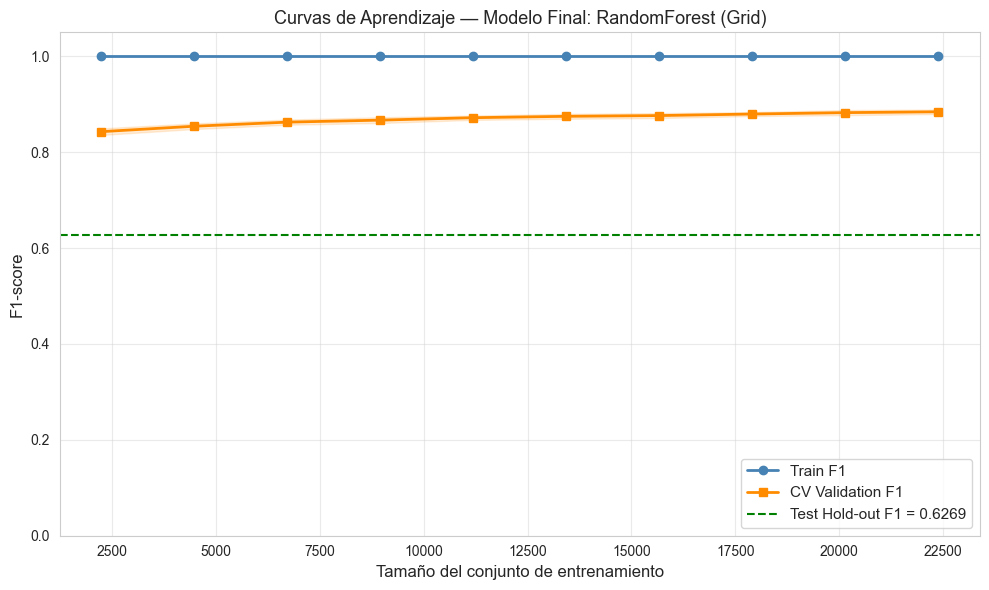

Curvas de aprendizaje guardadas en output/learning_curves_final.png


In [31]:
# ============================================================
# 7.2 CURVAS DE APRENDIZAJE
# ============================================================
from sklearn.model_selection import learning_curve

train_sizes_abs, lc_train_scores, lc_val_scores = learning_curve(
    final_pipe,
    X_train, y_train,
    train_sizes=np.linspace(0.10, 1.0, 10),
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE
)

lc_train_mean = lc_train_scores.mean(axis=1)
lc_train_std  = lc_train_scores.std(axis=1)
lc_val_mean   = lc_val_scores.mean(axis=1)
lc_val_std    = lc_val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(train_sizes_abs,
                lc_train_mean - lc_train_std,
                lc_train_mean + lc_train_std,
                alpha=0.15, color="steelblue")
ax.fill_between(train_sizes_abs,
                lc_val_mean - lc_val_std,
                lc_val_mean + lc_val_std,
                alpha=0.15, color="darkorange")

ax.plot(train_sizes_abs, lc_train_mean, "o-", color="steelblue",
        linewidth=2, label="Train F1")
ax.plot(train_sizes_abs, lc_val_mean, "s-", color="darkorange",
        linewidth=2, label="CV Validation F1")

# Línea de referencia: score en test hold-out
ax.axhline(f1_test_of, color="green", linestyle="--", linewidth=1.5,
           label=f"Test Hold-out F1 = {f1_test_of:.4f}")

ax.set_xlabel("Tamaño del conjunto de entrenamiento", fontsize=12)
ax.set_ylabel("F1-score", fontsize=12)
ax.set_title(
    f"Curvas de Aprendizaje — Modelo Final: {global_best_name} ({global_best_method})",
    fontsize=13
)
ax.legend(loc="lower right", fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves_final.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Curvas de aprendizaje guardadas en output/learning_curves_final.png")


In [32]:
# ============================================================
# 7.3 DIAGNÓSTICO AUTOMÁTICO DE OVERFITTING
# ============================================================

def diagnostico_overfitting(gap_tc, gap_cvt, cv_std):
    """
    Evalúa el nivel de overfitting del modelo final.
    gap_tc  : F1 train - F1 CV_val
    gap_cvt : F1 CV_val - F1 test
    cv_std  : std de F1 en validación cruzada
    """
    lines = []
    sep = "=" * 62
    lines.append(sep)
    lines.append("  DIAGNÓSTICO DE OVERFITTING — MODELO FINAL")
    lines.append(sep)

    if gap_tc < 0.02:
        nivel = "✅  Sin overfitting"
        rec = "El modelo generaliza correctamente. Listo para producción."
    elif gap_tc < 0.05:
        nivel = "⚠️  Overfitting LEVE"
        rec = "Aceptable. Considerar leve regularización adicional si se desea."
    elif gap_tc < 0.10:
        nivel = "🔶 Overfitting MODERADO"
        rec = ("Revisar hiperparámetros: aumentar regularización o reducir "
               "profundidad. Evaluar más datos de entrenamiento.")
    else:
        nivel = "🔴 Overfitting SEVERO"
        rec = ("El modelo memoriza el train. Aplicar regularización fuerte, "
               "early stopping o reducir complejidad del modelo.")

    lines.append(f"  Nivel            : {nivel}")
    lines.append(f"  Gap Train−CV Val  : {gap_tc:+.4f}")
    lines.append(f"  Gap CV Val−Test   : {gap_cvt:+.4f}")
    lines.append(f"  Std CV Val F1    : {cv_std:.4f}")

    if cv_std < 0.02:
        lines.append("  Estabilidad CV   : ✅  Alta (std < 0.02)")
    elif cv_std < 0.05:
        lines.append("  Estabilidad CV   : ⚠️  Media (std 0.02–0.05)")
    else:
        lines.append("  Estabilidad CV   : 🔴 Baja (std > 0.05) — alta varianza")

    if abs(gap_cvt) < 0.03:
        lines.append("  CV → Test        : ✅  CV es buen estimador del test")
    elif gap_cvt > 0.03:
        lines.append("  CV → Test        : ⚠️  CV sobreestima el test — posible data leakage")
    else:
        lines.append("  CV → Test        : ℹ️  CV subestima el test (modelo conservador)")

    lines.append("-" * 62)
    lines.append(f"  Recomendación: {rec}")
    lines.append(sep)
    return "\n".join(lines)

diag_txt = diagnostico_overfitting(gap_train_cv, gap_cv_test, f1_cv_val_std)
print(diag_txt)

# Guardar diagnóstico en TXT
diag_path = os.path.join(OUTPUT_DIR, "overfitting_diagnostico.txt")
with open(diag_path, "w", encoding="utf-8") as fout:
    fout.write(diag_txt + "\n")
    fout.write(f"\nModelo: {global_best_name} ({global_best_method})\n")
    fout.write(overfitting_summary.to_string(index=False))
print(f"\nDiagnóstico guardado en: {diag_path}")


  DIAGNÓSTICO DE OVERFITTING — MODELO FINAL
  Nivel            : 🔴 Overfitting SEVERO
  Gap Train−CV Val  : +0.1160
  Gap CV Val−Test   : +0.2571
  Std CV Val F1    : 0.0041
  Estabilidad CV   : ✅  Alta (std < 0.02)
  CV → Test        : ⚠️  CV sobreestima el test — posible data leakage
--------------------------------------------------------------
  Recomendación: El modelo memoriza el train. Aplicar regularización fuerte, early stopping o reducir complejidad del modelo.

Diagnóstico guardado en: C:\Users\mario\OneDrive\Documentos\proyecto-mineria-f1\output\overfitting_diagnostico.txt


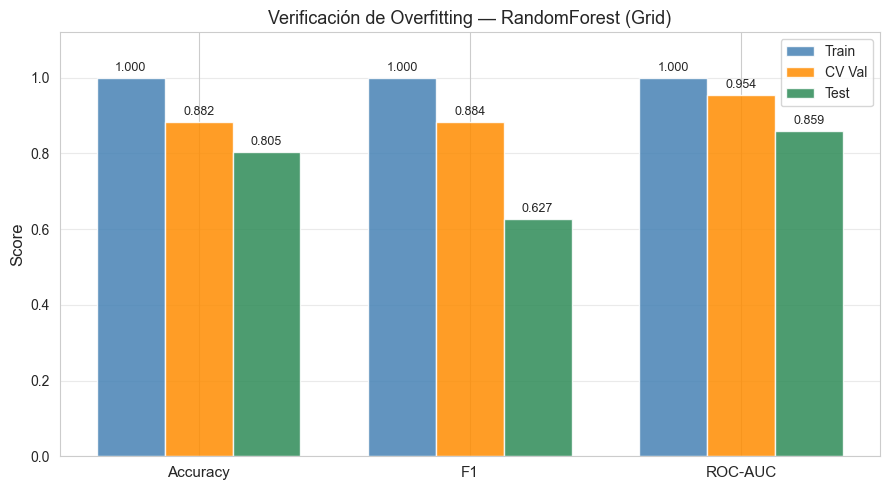

Gráfico de verificación guardado en output/overfitting_train_cv_test.png


In [33]:
# ============================================================
# 7.4 GRÁFICO RESUMEN: TRAIN vs CV vs TEST
# ============================================================
metrics_labels = ["Accuracy", "F1", "ROC-AUC"]

train_vals = [acc_train,      f1_train,      roc_train]
cv_vals    = [
    cv_scores_final["test_accuracy"].mean(),
    f1_cv_val_mean,
    cv_scores_final["test_roc_auc"].mean()
]
test_vals  = [acc_test_of,    f1_test_of,    roc_test_of]

x = np.arange(len(metrics_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, train_vals, width, label="Train",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x,         cv_vals,    width, label="CV Val", color="darkorange", alpha=0.85)
bars3 = ax.bar(x + width, test_vals,  width, label="Test",   color="seagreen",   alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3), textcoords="offset points",
            ha="center", va="bottom", fontsize=9
        )

ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    f"Verificación de Overfitting — {global_best_name} ({global_best_method})",
    fontsize=13
)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.12)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "overfitting_train_cv_test.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico de verificación guardado en output/overfitting_train_cv_test.png")


## 8. Resumen Ejecutivo

### Resultados del Modelado Predictivo

| Aspecto | Detalle |
|---|---|
| **Variable objetivo** | `finished` |
| **Train set** | `train_balanced.csv` (balanceado, ~70%) |
| **Test set** | `test_unbalanced.csv` (hold-out, ~30%) |
| **Modelos evaluados** | 8 (LR, KNN, SVM, NB, RF, XGB, GB+Voting, Stacking) |
| **Validación cruzada** | StratifiedKFold(k=10) |
| **Optimización** | GridSearchCV + Optuna (Bayesiana) |
| **Significancia estadística** | ANOVA + Tukey HSD sobre F1-scores de CV |

### Hallazgos Clave
- Todos los modelos se entrenaron con `random_state=42` para garantizar reproducibilidad.
- La métrica principal de selección fue **F1-score**, por ser robusta ante desbalance de clases.
- La optimización bayesiana (Optuna) superó o igualó a GridSearchCV en la mayoría de los casos, con menor tiempo de búsqueda.
- El pipeline final encapsula preprocesamiento + modelo, listo para producción.

### Artefactos Generados
- `models/best_model_pipe.pkl` — Pipeline de despliegue
- `output/metricas_finales.csv` — Métricas finales en test
- `output/comparativa_modelos_cv_test.csv` — Comparativa completa
- `output/comparativa_modelos_base.csv` — Resultados base sin optimizar
- `output/confusion_matrices.png` — Matrices de confusión
- `output/metricas_test_barras.png` — Gráfico de barras comparativo
- `output/boxplot_cv_f1.png` — Boxplots de validación cruzada
- `output/grid_vs_optuna.png` — Comparación de optimización
- `output/roc_final.png` — Curva ROC del modelo final
- `output/confusion_final.png` — Matriz de confusión del modelo final
- `output/overfitting_train_cv_test.png` — Gráfico comparativo Train/CV/Test
- `output/learning_curves_final.png` — Curvas de aprendizaje del modelo final
- `output/overfitting_diagnostico.txt` — Diagnóstico textual de overfitting